In [6]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [7]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria
!unzip -q cell-images-for-detecting-malaria.zip

!kaggle datasets download -d andrewmvd/leukemia-classification
!unzip -q leukemia-classification.zip

!kaggle datasets download -d florencetushabe/sickle-cell-disease-dataset
!unzip -q sickle-cell-disease-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:46<00:00, 15.1MB/s]

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/leukemia-classification
License(s): other
100% 867M/867M [00:50<00:00, 18.1MB/s]

Dataset URL: https://www.kaggle.com/datasets/florencetushabe/sickle-cell-disease-dataset
License(s): DbCL-1.0
100% 253M/253M [00:18<00:00, 14.6MB/s]



In [8]:
import os, shutil
from sklearn.model_selection import train_test_split

base_dir = "dataset"

for split in ["train", "val", "test"]:
    for cls in ["malaria", "normal", "leukemia", "sickle"]:
        os.makedirs(f"{base_dir}/{split}/{cls}", exist_ok=True)

def split_and_copy(files, src, cls):
    train, temp = train_test_split(files, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    for f in train:
        shutil.copy(os.path.join(src, f), f"{base_dir}/train/{cls}")
    for f in val:
        shutil.copy(os.path.join(src, f), f"{base_dir}/val/{cls}")
    for f in test:
        shutil.copy(os.path.join(src, f), f"{base_dir}/test/{cls}")

# Malaria
split_and_copy(os.listdir("cell_images/cell_images/Parasitized"),
               "cell_images/cell_images/Parasitized", "malaria")

# Normal
split_and_copy(os.listdir("cell_images/cell_images/Uninfected"),
               "cell_images/cell_images/Uninfected", "normal")

# Leukemia
split_and_copy(os.listdir("C-NMC_Leukemia/training_data/fold_0/all"),
               "C-NMC_Leukemia/training_data/fold_0/all", "leukemia")

# Sickle
sickle_files = []
for root, dirs, files in os.walk("Positive"):
    for f in files:
        if f.endswith((".jpg",".png",".jpeg")):
            sickle_files.append(os.path.join(root, f))

train, temp = train_test_split(sickle_files, test_size=0.3, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

for f in train:
    shutil.copy(f, f"{base_dir}/train/sickle")
for f in val:
    shutil.copy(f, f"{base_dir}/val/sickle")
for f in test:
    shutil.copy(f, f"{base_dir}/test/sickle")

print("Dataset ready ✅")

Dataset ready ✅


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.utils.class_weight import compute_class_weight

In [9]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    "dataset/val",
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 21356 images belonging to 4 classes.
Found 4610 images belonging to 4 classes.
Found 4609 images belonging to 4 classes.


In [ ]:
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(zip(np.unique(classes), class_weights))

print("Class Weights:", class_weights)

Class Weights: {np.int32(0): np.float64(3.1835122242098985), np.int32(1): np.float64(0.5535251425609123), np.int32(2): np.float64(0.5535251425609123), np.int32(3): np.float64(13.759664948453608)}


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)   
x = layers.Dropout(0.4)(x)

output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

loss_fn = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.05
)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,219,175 (16.09 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 384s 265ms/step - accuracy: 0.8852 - loss: 0.4545 - val_accuracy: 0.9080 - val_loss: 0.4262 - learning_rate: 0.0010
Epoch 2/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 329s 246ms/step - accuracy: 0.9171 - loss: 0.3391 - val_accuracy: 0.9176 - val_loss: 0.4031 - learning_rate: 0.0010
Epoch 3/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 321s 240ms/step - accuracy: 0.9226 - loss: 0.3317 - val_accuracy: 0.9247 - val_loss: 0.3842 - learning_rate: 0.0010
Epoch 4/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 312s 234ms/step - accuracy: 0.9219 - loss: 0.3290 - val_accuracy: 0.9143 - val_loss: 0.4085 - learning_rate: 0.0010
Epoch 5/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 320s 240ms/step - accuracy: 0.9227 - loss: 0.3274 - val_accuracy: 0.9328 - val_loss: 0.3740 - learning_rate: 0.0010
Epoch 6/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 332s 249ms/step - accuracy: 0.9260 - loss: 0.3217 - val_accuracy: 0.9334 - val_loss: 0.3689 - learning_rate: 0.0010
Epoch 7/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 331s 248ms

In [ ]:
# Unfreeze last layers
for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=loss_fn,   # 🔥 SAME LOSS
    metrics=['accuracy']
)

# history_fine = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=5,
#     class_weight=class_weights,
#     callbacks=[early_stop, reduce_lr]
# )

In [ ]:
model.save("hematology_final_model_14.keras")

In [ ]:
from google.colab import files

files.download("hematology_final_model_14.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

test_generator.reset()

preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

289/289 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       360
           1       0.97      0.94      0.96      2067
           2       0.94      0.97      0.96      2067
           3       1.00      1.00      1.00       116

    accuracy                           0.96      4610
   macro avg       0.98      0.98      0.98      4610
weighted avg       0.96      0.96      0.96      4610


Confusion Matrix:

[[ 360    0    0    0]
 [   2 1944  121    0]
 [   0   54 2013    0]
 [   0    0    0  116]]


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/hematology_final_model.keras", compile=False)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_generator.reset()

preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

289/289 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       360
           1       0.97      0.89      0.93      2067
           2       0.89      0.97      0.93      2067
           3       1.00      1.00      1.00       116

    accuracy                           0.94      4610
   macro avg       0.97      0.96      0.96      4610
weighted avg       0.94      0.94      0.94      4610

[[ 360    0    0    0]
 [   0 1830  237    0]
 [   0   56 2011    0]
 [   0    0    0  116]]


In [ ]:
confused_indices = []

for i in range(len(y_true)):
    if (y_true[i] == 1 and y_pred[i] == 2) or \
       (y_true[i] == 2 and y_pred[i] == 1):
        confused_indices.append(i)

print("Confused samples:", len(confused_indices))

Confused samples: 293


In [ ]:
import cv2
from tensorflow.keras.applications.efficientnet import preprocess_input

X_confused = []
y_confused = []

filepaths = test_generator.filepaths

for i in confused_indices[:300]:   # limit for speed
    img = cv2.imread(filepaths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    img = preprocess_input(img)

    X_confused.append(img)
    y_confused.append(y_true[i])

X_confused = np.array(X_confused)
y_confused = tf.keras.utils.to_categorical(y_confused, 4)

print("Confusion dataset shape:", X_confused.shape)

Confusion dataset shape: (293, 224, 224, 3)


In [ ]:
# Freeze most layers
for layer in model.layers[:-15]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_confused,
    y_confused,
    epochs=5,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=2)]
)

Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 522ms/step - accuracy: 0.4710 - loss: 0.8146
Epoch 2/5


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4846 - loss: 0.8120
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4949 - loss: 0.7730
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4983 - loss: 0.7275
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5461 - loss: 0.6980


In [ ]:
def corrected_prediction(img_array):
    preds = model.predict(img_array)

    # 🔥 bias correction
    preds[0][1] *= 1.1   # malaria boost
    preds[0][2] *= 0.9   # normal reduce

    return np.argmax(preds), np.max(preds)

In [ ]:
test_generator.reset()

preds = model.predict(test_generator)

# apply bias correction
for i in range(len(preds)):
    preds[i][1] *= 1.1
    preds[i][2] *= 0.9

y_pred = np.argmax(preds, axis=1)

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

289/289 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       360
           1       0.93      0.94      0.94      2067
           2       0.94      0.93      0.94      2067
           3       0.94      1.00      0.97       116

    accuracy                           0.94      4610
   macro avg       0.95      0.97      0.96      4610
weighted avg       0.94      0.94      0.94      4610

[[ 360    0    0    0]
 [   0 1941  120    6]
 [   0  138 1927    2]
 [   0    0    0  116]]


In [ ]:
import numpy as np

# Reset generator
test_generator.reset()

# Predictions
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

filepaths = test_generator.filepaths

print("Prediction completed ✅")

289/289 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step
Prediction completed ✅


In [ ]:
correct = []
incorrect = []

for i in range(len(y_true)):
    if y_true[i] == y_pred[i]:
        correct.append(i)
    else:
        incorrect.append(i)

print("✅ Correct:", len(correct))
print("❌ Incorrect:", len(incorrect))

✅ Correct: 4336
❌ Incorrect: 274


In [ ]:
import os
import cv2

os.makedirs("misclassified", exist_ok=True)

for i in incorrect[:100]:  # limit to 100
    img = cv2.imread(filepaths[i])

    true_label = y_true[i]
    pred_label = y_pred[i]

    filename = f"img_{i}_true{true_label}_pred{pred_label}.jpg"

    cv2.imwrite(os.path.join("misclassified", filename), img)

print("Saved misclassified images ✅")

Saved misclassified images ✅


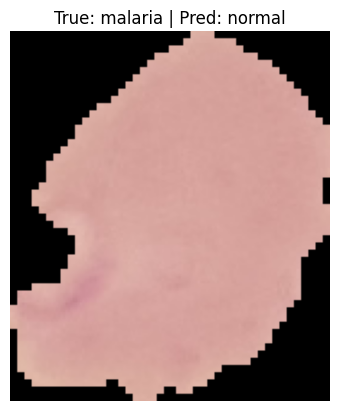

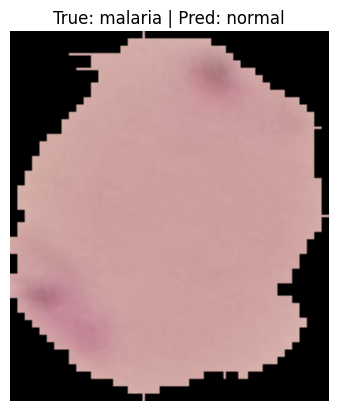

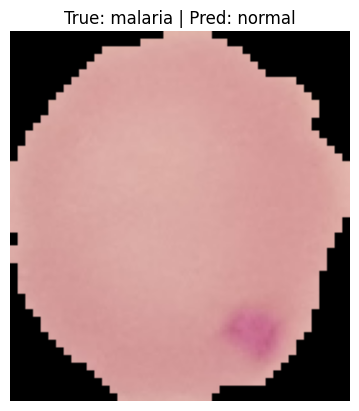

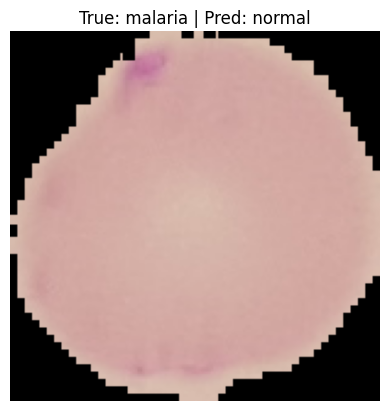

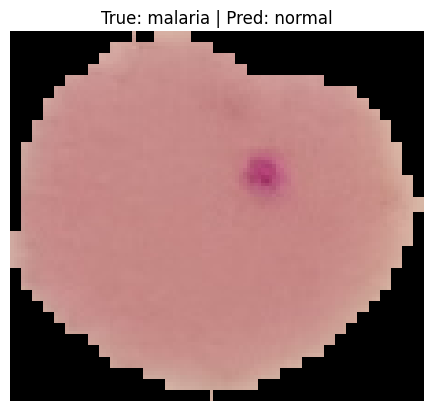

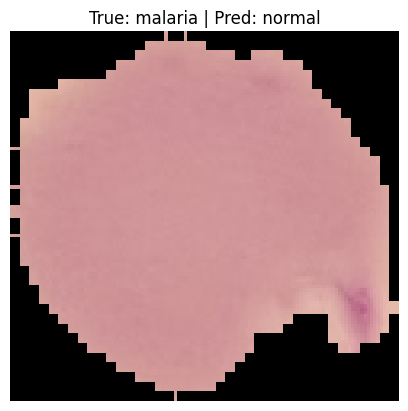

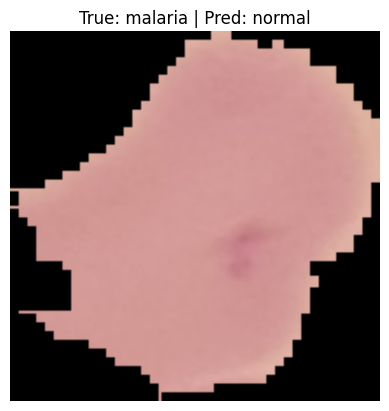

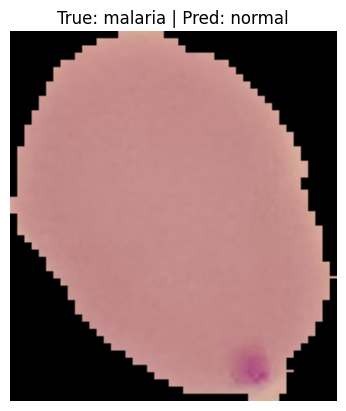

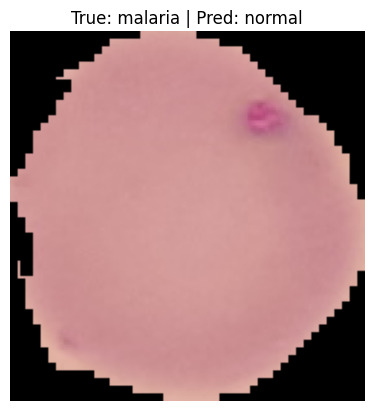

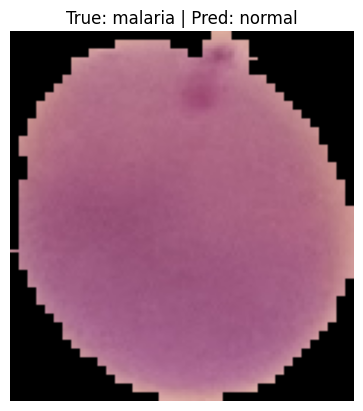

In [ ]:
import matplotlib.pyplot as plt

class_names = ['leukemia','malaria','normal','sickle']

for i in incorrect[:10]:
    img = cv2.imread(filepaths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"True: {class_names[y_true[i]]} | Pred: {class_names[y_pred[i]]}")
    plt.axis("off")
    plt.show()

In [ ]:
from collections import defaultdict

errors = defaultdict(int)

for i in incorrect:
    key = f"{class_names[y_true[i]]} → {class_names[y_pred[i]]}"
    errors[key] += 1

print("\n🔍 Error Breakdown:")
for k, v in errors.items():
    print(f"{k}: {v}")


🔍 Error Breakdown:
malaria → normal: 175
malaria → sickle: 6
normal → malaria: 91
normal → sickle: 2


In [ ]:
print("\n⚠️ Wrong Predictions Confidence:")

for i in incorrect[:10]:
    confidence = np.max(preds[i])
    print(f"Index {i} → Confidence: {confidence:.3f}")


⚠️ Wrong Predictions Confidence:
Index 360 → Confidence: 0.577
Index 403 → Confidence: 0.641
Index 424 → Confidence: 0.557
Index 449 → Confidence: 0.756
Index 452 → Confidence: 0.531
Index 458 → Confidence: 0.668
Index 469 → Confidence: 0.577
Index 470 → Confidence: 0.699
Index 471 → Confidence: 0.542
Index 472 → Confidence: 0.503


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

In [18]:
model = tf.keras.models.load_model("/content/hematology_optimized.keras", compile=False)
print("Model loaded ✅")

Model loaded ✅


In [19]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
print("Classes:", class_names)

Found 4609 images belonging to 4 classes.
Classes: ['leukemia', 'malaria', 'normal', 'sickle']


In [20]:
test_generator.reset()

preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step


In [21]:
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


📊 Classification Report:

              precision    recall  f1-score   support

    leukemia       1.00      0.99      0.99       360
     malaria       0.95      0.90      0.93      2066
      normal       0.91      0.95      0.93      2067
      sickle       1.00      0.97      0.99       116

    accuracy                           0.93      4609
   macro avg       0.96      0.95      0.96      4609
weighted avg       0.94      0.93      0.93      4609



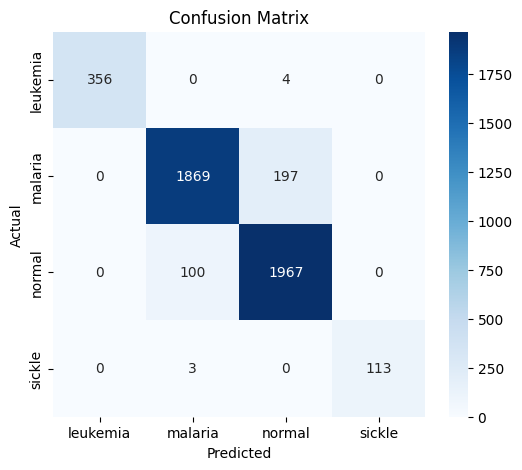

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

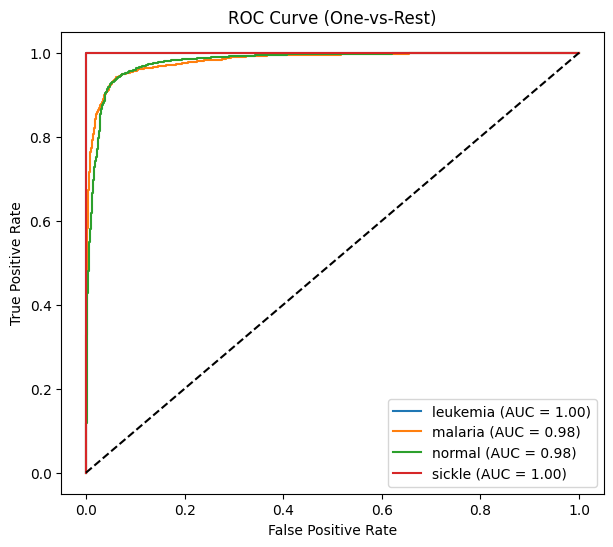

In [23]:
n_classes = len(class_names)

# Binarize labels
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

In [15]:
print("\n🔥 AUC Scores:")

for i in range(n_classes):
    print(f"{class_names[i]}: {roc_auc[i]:.3f}")

macro_auc = sum(roc_auc.values()) / n_classes
print("Macro Average AUC:", round(macro_auc, 3))


🔥 AUC Scores:
leukemia: 1.000
malaria: 0.990
normal: 0.990
sickle: 1.000
Macro Average AUC: 0.995


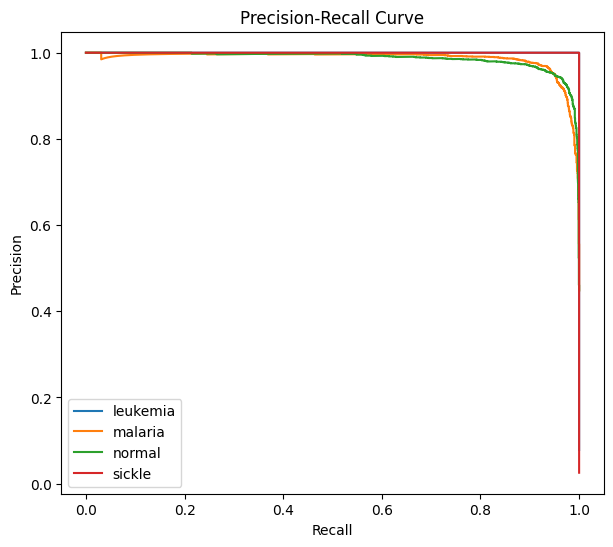

In [16]:
plt.figure(figsize=(7,6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], preds[:, i])
    plt.plot(recall, precision, label=f"{class_names[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()